In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#To suppress all warnings
import warnings
warnings.filterwarnings('ignore')

In [5]:
#Q1.1: Load dataset
df = sns.load_dataset('tips')
#Q1.2: Display first rows
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
#Q1.3: Dataset shape and columns
df.shape



(244, 7)

In [8]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [21]:
#Q2.1: Weekend
import pandas as pd

df['day_type'] = df['day'].apply(
    lambda x: 'Weekend' if x in ['Sat', 'Sun'] else 'Weekday'
)

weekends = df[df['day'].isin(['Sat', 'Sun'])]
weekends.head()

,total_bill,tip,sex,smoker,day,time,size,day_type
0,16.99,1.01,Female,No,Sun,Dinner,2,Weekend
1,10.34,1.66,Male,No,Sun,Dinner,3,Weekend
2,21.01,3.50,Male,No,Sun,Dinner,3,Weekend
3,23.68,3.31,Male,No,Sun,Dinner,2,Weekend
4,24.59,3.61,Female,No,Sun,Dinner,4,Weekend


In [13]:
# weekday
weekdays = df[df['day'].isin(['Mon','Tue', 'Wed', 'Thur', 'Fri'])]
weekdays.head()

,total_bill,tip,sex,smoker,day,time,size,day_type
77,27.20,4.00,Male,No,Thur,Lunch,4,Weekday
78,22.76,3.00,Male,No,Thur,Lunch,2,Weekday
79,17.29,2.71,Male,No,Thur,Lunch,2,Weekday
80,19.44,3.00,Male,Yes,Thur,Lunch,2,Weekday
81,16.66,3.40,Male,No,Thur,Lunch,2,Weekday


In [18]:
result = pd.DataFrame({
    "Weekends": weekends[['tip','total_bill']].mean(),
    "Weekdays": weekdays[['tip','total_bill']].mean()
})
print(result)


             Weekends   Weekdays
tip          3.115276   2.762840
total_bill  20.893006  17.558148


In [ ]:
#Answer Q2.3: Compare this with weekday customers.
Weekend customers spend more and give higher tips on average than weekday customers.

In [19]:
# Q3.1: Sort customers by total_bill (descending).
df_sorted = df.sort_values(by='total_bill', ascending=False)
df_sorted.head()


,total_bill,tip,sex,smoker,day,time,size,day_type
170,50.81,10.00,Male,Yes,Sat,Dinner,3,Weekend
212,48.33,9.00,Male,No,Sat,Dinner,4,Weekend
59,48.27,6.73,Male,No,Sat,Dinner,4,Weekend
156,48.17,5.00,Male,No,Sun,Dinner,6,Weekend
182,45.35,3.50,Male,Yes,Sun,Dinner,3,Weekend


In [20]:
# Q3.2:Display the top 10 highest bills.
df_sorted.head(10)

,total_bill,tip,sex,smoker,day,time,size,day_type
170,50.81,10.00,Male,Yes,Sat,Dinner,3,Weekend
212,48.33,9.00,Male,No,Sat,Dinner,4,Weekend
59,48.27,6.73,Male,No,Sat,Dinner,4,Weekend
156,48.17,5.00,Male,No,Sun,Dinner,6,Weekend
182,45.35,3.50,Male,Yes,Sun,Dinner,3,Weekend
102,44.30,2.50,Female,Yes,Sat,Dinner,3,Weekend
197,43.11,5.00,Female,Yes,Thur,Lunch,4,Weekday
142,41.19,5.00,Male,No,Thur,Lunch,5,Weekday
184,40.55,3.00,Male,Yes,Sun,Dinner,2,Weekend
95,40.17,4.73,Male,Yes,Fri,Dinner,4,Weekday


In [ ]:
#What do you notice about their group sizes?
This suggests that bigger groups tend to generate higher total bills, especially during dinner and on weekends.

In [23]:
#Q4.1: missing values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
day_type      0
dtype: int64


In [ ]:
#Why missing values are dangerous in machine learning.
Missing values are dangerous in machine learning because they can break many algorithms,
reduce data quality, and lead to biased or incorrect predictions if the missing data isn’t handled properly.

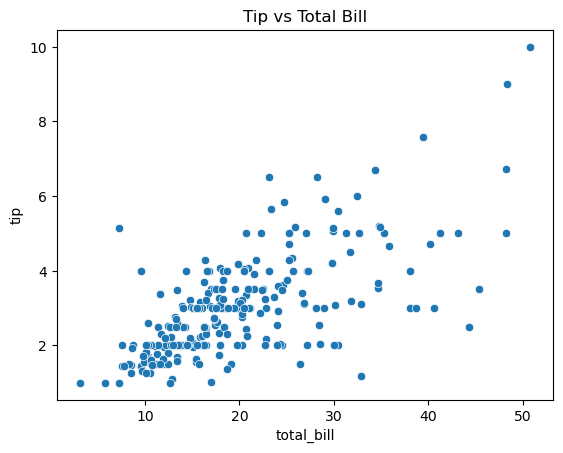

In [24]:
#Q5.1: Tip vs Total Bill (scatter plot)
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Tip vs Total Bill')
plt.show()

In [ ]:
# There is a clear positive relationship between total bill and tip, 
meaning customers tend to give higher tips when they spend more.

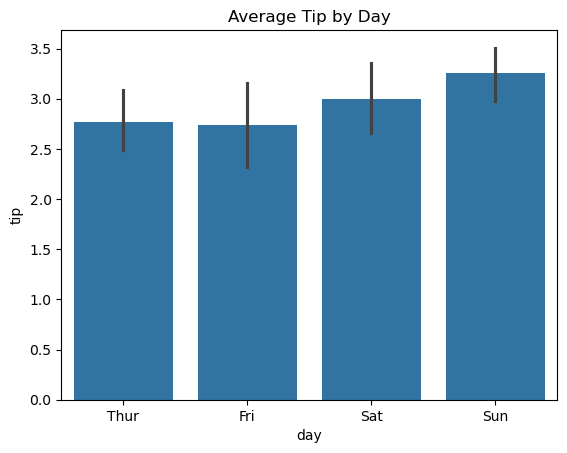

In [27]:
# Q5.1: Average tip by day (bar plot)
sns.barplot(x='day', y='tip', data=df)
plt.title('Average Tip by Day')
plt.show()
#Average tips are higher on weekends, especially on Sunday, compared to weekdays.

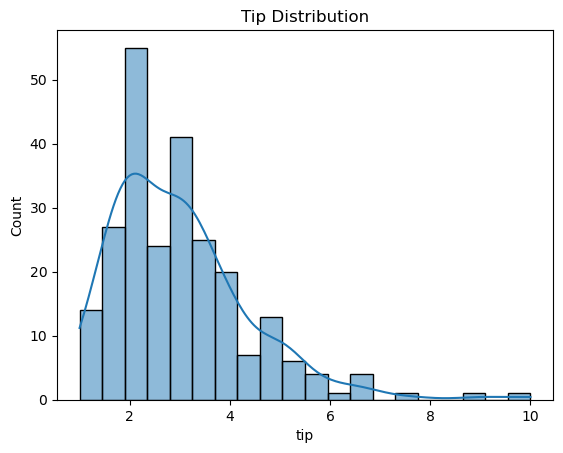

In [26]:
# Q5.1: Tip distribution (histogram)
sns.histplot(df['tip'], bins=20, kde=True)
plt.title('Tip Distribution')
plt.show()


In [ ]:
Most tips are small and clustered around lower values, 
with a right-skewed distribution showing that large tips are less common.

In [ ]:
Customers tip more when their total bill is higher, so larger spending groups usually leave bigger tips. 
Tips are generally highest on weekends, especially on Sunday, compared to weekdays. 
This suggests that weekend dining may involve larger parties and longer meals, which increases both bills and tips. 
For restaurant management, this insight helps plan staffing because weekends likely need more servers to handle higher demand.
Managers can also schedule more experienced staff on weekend dinners to improve service and maximize tips. 
They could run promotions on slower weekdays to increase traffic and potentially raise tip totals.
Finally, tracking tipping patterns can help with better shift planning and fair tip distribution.

Answer Q6:
Customers — Tip more on weekends and when their total bill is higher.
Restaurant managers — Use this to schedule more staff and stronger servers on weekend shifts, and boost weekday sales with targeted deals.

In [ ]:
import seaborn as sns
df = sns.load_dataset('tips')
